**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 须遵守与协作相同的政策。与其他协作者一样，每位学生都必须独立于交互输出撰写解答，并在提交内容中注明协作的性质。使用生成式 AI 工具完成作业中的实质性部分不符合本作业的精神，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。\n

# 去噪扩散概率模型

到目前为止，我们探索的都是判别模型，它们被训练为产生带标签的输出。这些任务从直接的图像分类，到仍被表述为分类问题的句子生成不等；后者的标签位于词汇空间中，并使用循环机制捕获由多个词组成的标签。现在，我们将扩展工具箱，构建一个生成模型，使其能够创造与给定训练图像集合相似的新图像。

生成模型有许多种，包括生成对抗网络（GAN）、自回归模型、归一化流模型和变分自编码器（VAE），它们都能合成引人注目的图像。然而在 2020 年，Ho 等人将扩散概率模型与去噪分数匹配相结合，提出了去噪扩散概率模型（DDPM）。由此得到的生成模型既容易训练，又足以生成复杂的高质量图像。下面将从较高层次概述 DDPM。更多细节请参阅课程幻灯片和 DDPM 原论文 [1]。

# 前向过程
设 $q(x_0)$ 为干净数据集图像的分布。我们将前向加噪过程定义为由多个小幅加噪步骤组成的马尔可夫链：

$$q(x_t | x_{t-1}) \sim N(x_t; \sqrt{1-\beta_t} x_{t-1} , \beta_t I)$$

其中，逐步方差 $(\beta_1, ..., \beta_T)$ 决定噪声调度。根据高斯分布的性质，可以将 $q(x_t | x_0)$ 写成如下闭式形式：

$$q(x_t | x_0) \sim N(x_t; \sqrt{\bar{\alpha}_t} x_0 , (1-\bar{\alpha}_t) I)$$

其中 $\alpha_t = 1-\beta_t$，且 $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_t$。如果噪声调度 $(\beta_1, ..., \beta_T)$ 设置得当，最终分布 $q(x_T)$ 将与纯高斯噪声 $N(0, I)$ 无法区分。

回顾一下，从高斯分布 $x \sim N(\mu, \sigma^2)$ 中采样等价于计算 $\sigma * \epsilon + \mu$，其中 $\epsilon \sim N(0, 1)$。因此，给定 $x_{t-1}$ 或 $x_0$ 后，分别从 $q(x_t | x_{t-1})$ 或 $q(x_t | x_0)$ 中采样都很直接。正因如此，前向过程十分简单，不需要学习。

# 反向过程
反向过程通过多个步骤，从纯噪声 $x_T$ 重建干净图像 $x_0$。用 $p(x_{t-1} | x_t)$ 表示 $q(x_t | x_{t-1})$ 的反向步骤。
第一个关键洞见是：学习逆转每一个独立的去噪步骤，比一次性逆转整个前向过程容易。换言之，对每个 $t$ 学习 $p(x_{t-1} | x_t)$，比直接学习 $p(x_0 | x_T)$ 更容易。

不过，学习 $p(x_{t-1} | x_t)$ 仍然很困难。尽管 $q(x_t | x_{t-1})$ 是高斯分布，$p(x_{t-1} | x_t)$ 却可能具有任意复杂的形式，而且几乎肯定不是高斯分布。与高斯分布这样简单的参数分布相比，对任意分布建模并从中采样要困难得多。

第二个关键洞见是：如果前向过程中的逐步噪声 $\beta_t$ 足够小，那么反向步骤 $p(x_{t-1} | x_t)$ 也接近高斯分布。因此，我们只需估计其均值和方差。实践中，将 $p(x_{t-1} | x_t)$ 的方差设为与 $\beta_t$ 一致（即与前向步骤相同）便能取得良好效果。这样，学习反向过程就归结为学习均值 $\mu(x_t, t; \theta)$，其中 $\theta$ 表示神经网络的参数。

# 去噪目标
生成模型通过最小化数据集样本的期望负对数似然 $\mathbb{E}[-\log{p_\theta(x_0)}]$ 进行优化。每个样本的似然可以表示为：$p_\theta(x_0) = p(x_T)\prod_{t=1}^T p(x_{t-1} | x_t)$。由于这一目标在许多情况下难以直接计算，各类生成模型通常优化负对数似然的变分下界。

Ho 等人证明，这一目标等价于最小化以下去噪损失：

$$\mathbb{E}_{t, x_0, \epsilon}\left[ \| \epsilon - \epsilon_\theta (\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, t ) \|^2 \right]$$

其中，$t$ 在 1 到 T 之间均匀采样，$x_0$ 是干净样本，$\epsilon$ 从标准高斯分布 $N(0, I)$ 中采样，$\epsilon_\theta$ 是一个神经网络模型，经过训练后能够根据输入的带噪样本 $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ 预测噪声 $\epsilon$。换言之，$\epsilon_\theta$ 学习对输入的带噪图像进行去噪。注意，这等价于预测干净样本，因为依据等式 $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$，可以由带噪图像和干净样本恢复噪声。

[1] Denoising Diffusion Probabilistic Models. Jonathan Ho, Ajay Jain, Pieter Abbeel. [链接](https://arxiv.org/pdf/2006.11239)

# 本 Notebook 的内容
我们将实现并训练一个 DDPM 模型，根据文本提示生成 32 x 32 的小型表情符号图像。首先，根据论文 [1] 的公式（4）实现前向加噪过程。然后构建一个 UNet 模型，它以 $x_t$ 和 $t$ 为输入（也可以加入文本提示等其他条件），并输出一个形状与 $x_t$ 相同的张量。最后，我们将实现去噪目标并训练 DDPM 模型。

我们使用预训练 CLIP [2] 模型的文本编码器，将输入文本编码为 512 维向量。为了加快训练，我们已经预先编码了训练集中的文本数据。

[2] Learning transferable visual models from natural language supervision. Radford et. al. [链接](https://github.com/openai/CLIP)

In [2]:
import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import torchvision.utils as tv_utils
from cs231n.emoji_dataset import EmojiDataset
from cs231n.gaussian_diffusion import GaussianDiffusion

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-10, np.abs(x) + np.abs(y))))


In [3]:
# First, let's load and visualize the dataset.
# Each sample of the dataset is a tuple: (image, {"text_emb": <tensor>, "text": <string>})
# We will use a pretrained text-encoder to encode text into an embedding vector.
# We have pre-encoded the dataset texts into embeddings for faster training.
image_size = 32
dataset = EmojiDataset(image_size)


emoji_data.npz already downloaded.
text_embeddings.pt already downloaded.


In [4]:
def visualize_samples(dataset, num_samples=25, grid_size=(5, 5)):
    # Randomly sample indices
    indices = random.sample(range(len(dataset)), num_samples)
    samples = [dataset[i] for i in indices]

    # Inspect one sample
    img_shape = list(samples[0][0].shape)
    emb_shape = list(samples[0][1]["text_emb"].shape)
    print(f"One sample: (image: {img_shape}, {{ \"text_emb\": {emb_shape}, \"text\": string }})")

    # Extract images and texts
    images = torch.stack([sample[0] for sample in samples])  # Stack images
    texts = [sample[1]["text"] for sample in samples]  # Extract text descriptions

    # Create a grid of images
    grid_img = tv_utils.make_grid(images, nrow=grid_size[1], padding=2)

    # Convert to numpy for plotting
    grid_img = grid_img.permute(1, 2, 0).numpy()

    # Plot the images
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(grid_img)
    ax.axis("off")

    # Add text annotations
    grid_w, grid_h = grid_size
    img_w, img_h = grid_img.shape[1] // grid_w, grid_img.shape[0] // grid_h

    for i, text in enumerate(texts):
        row, col = divmod(i, grid_w)
        x, y = col * img_w, row * img_h
        ax.text(x+5, y+5, text[:30], fontsize=8, color='white', bbox=dict(facecolor='black', alpha=0.5))

    plt.show()

visualize_samples(dataset)

One sample: (image: [3, 32, 32], { "text_emb": [512], "text": string })


<Figure size 1000x1000 with 1 Axes>

## q_sample

现在定义前向加噪过程。请阅读 `cs231n/gaussian_diffusion.py` 中的 `GaussianDiffusion` 类，并参考 DDPM 原论文 [1] 中的公式。实现 `q_sample` 方法并在下方测试；相对误差应为零。

In [5]:
# Test GaussianDiffusion.q_sample method
sz = 2
b = 3

diffusion = GaussianDiffusion(
      model=None,
      image_size=sz,
      timesteps=1000,
      beta_schedule="sigmoid",
)

t = torch.tensor([0, 300, 999]).long()
x_start = torch.linspace(-0.9, 0.6, b*3*sz*sz).view(b, 3, sz, sz)
noise = torch.linspace(-0.7, 0.8, b*3*sz*sz).view(b, 3, sz, sz)
x_t = diffusion.q_sample(x_start, t, noise)

expected_x_t = np.array([
    [
        [[-0.9119949, -0.86840147], [-0.8248081, -0.7812148]],
        [[-0.7376214, -0.694028], [-0.65043473, -0.6068413]],
        [[-0.563248, -0.51965463], [-0.47606122, -0.43246788]],
    ],
    [
        [[-0.42800453, -0.37039882], [-0.31279305, -0.2551873]],
        [[-0.19758154, -0.1399758], [-0.08237009, -0.024764337]],
        [[0.032841414, 0.090447165], [0.14805292, 0.20565866]],
    ],
    [
        [[0.32864183, 0.37152246], [0.41440308, 0.45728368]],
        [[0.50016433, 0.5430449], [0.5859255, 0.6288062]],
        [[0.67168677, 0.7145674], [0.757448, 0.8003287]],
    ],
]).astype(np.float32)

# Should see zero relative error
print("x_t error: ", rel_error(x_t.numpy(), expected_x_t))

x_t error:  5.104469e-07


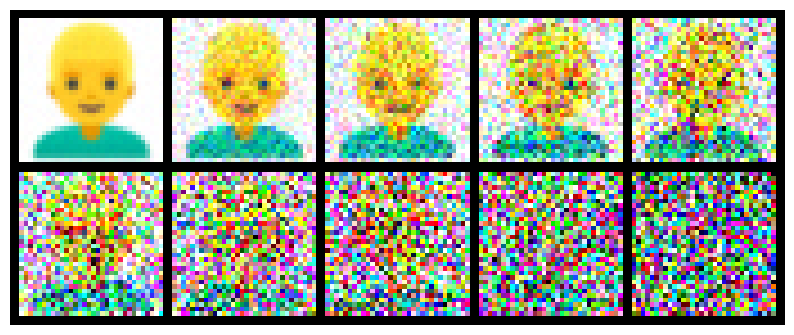

In [6]:
# Let's visualize the noisy images at various timesteps.
diffusion = GaussianDiffusion(
      model=None,
      image_size=image_size,
      timesteps=1000,
)

B = 10
img = dataset[770][0]  # 3 x H x W
x_start = img[None].repeat(B, 1, 1, 1)  # B x 3 x H x W
noise = torch.randn_like(x_start)  # B x 3 x H x W
t = torch.linspace(0, 1000-1, B).long()

x_start = diffusion.normalize(x_start)
x_t = diffusion.q_sample(x_start, t, noise)
x_t = diffusion.unnormalize(x_t).clamp(0, 1)
grid_img = tv_utils.make_grid(x_t, nrow=5, padding=2)
grid_img = grid_img.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid_img)
ax.axis("off")
plt.show()

扩散模型既可以预测干净图像，也可以预测噪声，因为二者可以相互推导（参见上面的“去噪目标”部分）。实现 `predict_start_from_noise` 和 `predict_noise_from_start` 方法，并在下方测试；相对误差应小于 1e-5。

In [7]:
# Test `predict_noise_from_start` and `predict_start_from_noise`
sz = 2
b = 3

diffusion = GaussianDiffusion(
      model=None,
      image_size=sz,
      timesteps=1000,
      beta_schedule="sigmoid",
)

t = torch.tensor([1, 300, 998]).long()
x_start = torch.linspace(-0.91, 0.67, b*3*sz*sz).view(b, 3, sz, sz)
noise = torch.linspace(-0.73, 0.81, b*3*sz*sz).view(b, 3, sz, sz)
x_t = diffusion.q_sample(x_start, t, noise)

pred_noise = diffusion.predict_noise_from_start(x_t, t, x_start)
pred_x_start = diffusion.predict_start_from_noise(x_t, t, noise)

# Should relative errors around 1e-5 or less
print("noise error: ", rel_error(pred_noise.numpy(), noise.numpy()))
print("x_start error: ", rel_error(pred_x_start.numpy(), x_start.numpy()))

noise error:  1.0600407e-06
x_start error:  1.8902663e-06


## UNet 模型

定义好前向过程后，接下来定义用于对输入图像去噪的 UNet 模型。UNet 是一种为分割、风格迁移等图像到图像任务设计的神经网络架构。它包含一个编码器（或下采样模块），将输入图像转换为一组层次化特征，其空间分辨率逐渐降低、特征维度逐渐增大；解码器（或上采样模块）则逐步恢复空间分辨率，对特征进行上采样，其结构与编码器相互对应。在每一层解码器中，来自相应编码器层的特征会被拼接，从而为细节信息提供直接通路。这种方法减轻了瓶颈层的负担，使其能够专注于捕获高级表征，而不必记忆细节。

这里使用 UNet，是因为输入和输出都是尺寸相同且彼此对齐的图像：C x H x W。UNet 中每个 ResNet 块还会接收一个名为 context 的附加条件向量。我们通过编码扩散时间步和文本提示来生成 context 向量。

运行下面的单元格，可查看 UNet 架构的概要。每个红框表示一个 ResNet 块，其中包含 2 或 3 个保持特征图空间分辨率不变的卷积层。为清晰起见，图中省略了输入每个 ResNet 块的 context 向量。每个框下方的形状表示该块输出张量的形状。额外的箭头表示跳跃连接，使 U-Net 能够在输出中保留细粒度细节。例如，形状为 (d, h, w) 的 `layer1_block1` 输出会与同样形状为 (d, h, w) 的 `layer4_block1` 输出拼接，再传给 `layer4_block2`。因此，`layer4_block2` 接收的输入形状为 (2*d, h, w)。

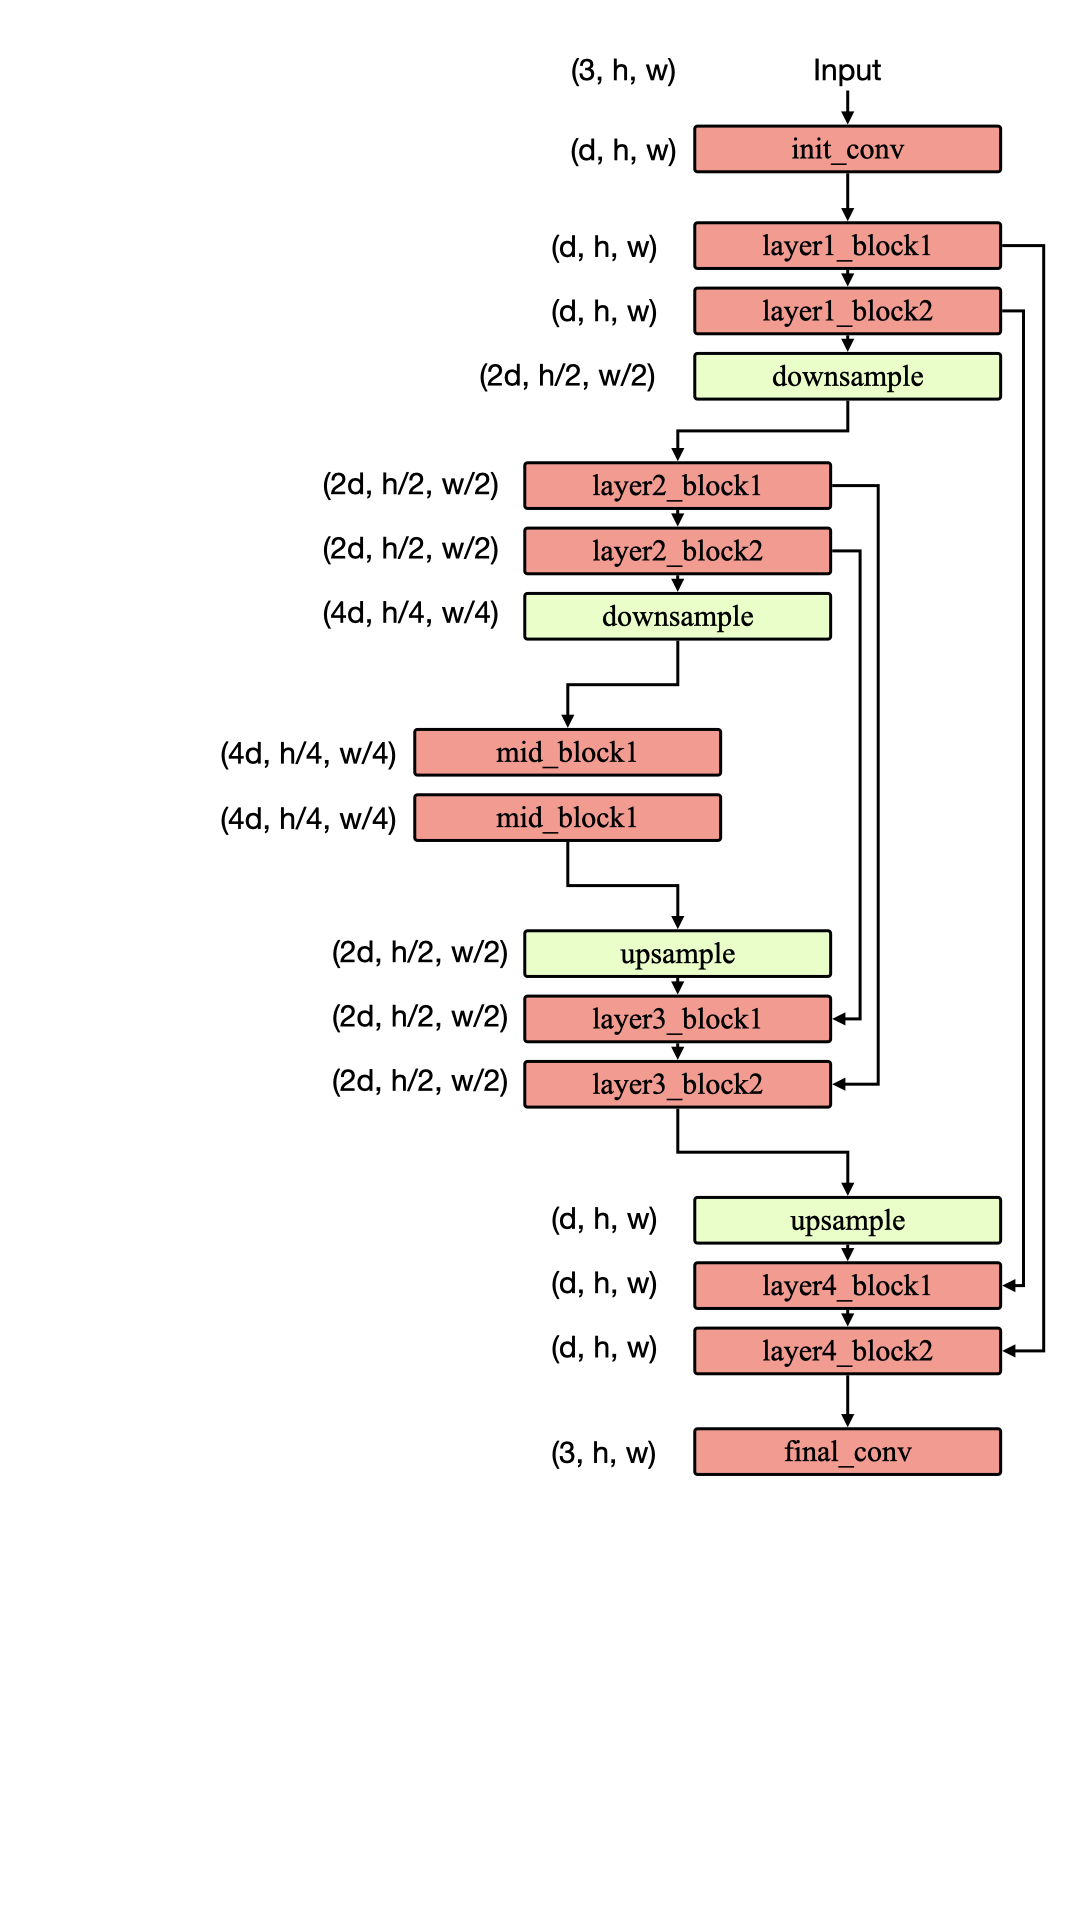

In [7]:
from IPython.display import Image
Image('unet.png')

实现 `cs231n/unet.py` 中的 `Unet.__init__` 方法，定义 UNet 模型的上采样块和下采样块，然后在下方测试。如果实现正确，你不会看到任何错误。调用 `Unet(dim=d, condition_dim=condition_dim, dim_mults=(2,4))` 应能成功创建与上图架构对应的 UNet 模型。

In [8]:
from cs231n.unet import Unet, ResnetBlock, Downsample, Upsample

dim = 2
condition_dim = 4
dim_mults = (1, 2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)


# Check number of layers
assert len(unet.downs) == len(dim_mults), "Number of Unet downsampling blocks is wrong."
assert len(unet.ups) == len(dim_mults), "Number of Unet upsampling blocks is wrong."


# Check layers
try:
  expected_downs_dims = [2, 2, 8, 2, 2, 8, 2, 2, 8, 2, 2, 8, 4, 4, 8, 4, 4, 8]
  downs_dims = [
      d for m in unet.downs for d in [
          m[0].dim, m[0].dim_out, m[0].context_dim, m[1].dim, m[1].dim_out, m[1].context_dim,
      ]
  ]
  assert downs_dims == expected_downs_dims, "Dimensions don't match"
except Exception as e:
  raise RuntimeError("Downsampling blocks wrongly configured") from e


try:
  expected_ups_dims = [8, 4, 8, 8, 4, 8, 4, 2, 8, 4, 2, 8, 4, 2, 8, 4, 2, 8]
  ups_dims = [
      d for m in unet.ups for d in [
          m[1].dim, m[1].dim_out, m[1].context_dim, m[2].dim, m[2].dim_out, m[2].context_dim,
      ]
  ]
  assert ups_dims == expected_ups_dims, "Dimensions don't match"
except Exception as e:
  raise RuntimeError("Upsampling blocks wrongly configured") from e

# Check number of parameters
num_params = sum(p.numel() for p in unet.parameters())
expected_num_params = 6499
assert num_params == expected_num_params, "Unet model creation is wrong!"


补全 `cs231n/unet.py` 中的 `Unet.forward` 方法，并在下方测试。暂时不用考虑 `Unet.cfg_forward` 方法；相对误差应小于 1e-6。

In [9]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

b = 2
h = w = 4
inp_x = torch.randn(b, 3, h, w)
inp_text_emb = torch.randn(b, condition_dim)
inp_t = torch.tensor([8, 25]).long()
out = unet.forward(x=inp_x, time=inp_t,
                   model_kwargs={"text_emb": inp_text_emb}).detach().numpy()

expected_out = np.array(
      [[[[ 0.3530089,   0.49302575,  0.55152094,  0.20567769],
         [ 1.1295223,   0.05811183,  0.2143015,   0.23898259],
         [ 0.44839963,  1.0291728,   0.18519637,  0.21956968],
         [ 0.7035912,   0.716347,    0.9166326,  -0.11552593]],
        [[ 0.04585427, -0.26847702,  0.08526254,  0.2396591 ],
         [ 0.2858743,  -0.29726404,  0.02462834,  0.2350314 ],
         [ 0.3121434,   0.3962962,   0.65541625, -0.300183  ],
         [ 0.3409412,   0.35369393,  0.37445623,  0.10297439]],
        [[ 0.49440542,  0.72878885,  0.6669705,   0.56822944],
         [ 1.0084232,   0.19204213,  0.61240125,  0.575651  ],
         [ 0.6452671,   0.91168964,  0.6458106,   0.25952405],
         [ 0.7147298,   0.7707498,   0.88941365,  0.35422024]]],
       [[[ 0.3186316,  -0.17632714,  0.440247,    0.05124736],
         [ 0.6866561,   0.3019496,   0.18366373,  0.42941707],
         [-0.09776017,  0.55849403,  0.30689716,  0.12954405],
         [ 0.3667726,   0.740231,    0.43682802,  0.08275545]],
        [[-0.29714173, -0.28515863, -0.02289355,  0.05637485],
         [-0.10230345,  0.182563,    0.8107456,   0.18209176],
         [ 0.57062995,  0.07061654,  0.2864037,   0.17969263],
         [ 0.31491554,  0.5652035,   0.3810383,   0.05889529]],
        [[ 0.14559639,  0.36408228,  0.5657894,   0.24066216],
         [ 0.4431491,   0.38140664,  1.1457629,   0.40314198],
         [ 0.6673274,   0.5922724,   0.44549578,  0.5544277 ],
         [ 0.5405652,   0.88729244,  0.66340685,  0.23414826]]]])

print("forward error: ", rel_error(out, expected_out))

forward error:  1.4688642710356004e-05


# p_losses

模型实现完成后，来编写 DDPM 的去噪训练步骤。如前所述，优化去噪损失等价于最小化数据集的期望负对数似然。补全 `cs231n/gaussian_diffusion.py` 中的 `GaussianDiffusion.p_losses` 方法，并在下方测试；相对误差应小于 1e-6。

In [10]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

h = w = 4
b = 3
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="sigmoid",
      objective="pred_x_start",
)

inp_x = torch.randn(b, 3, h, w)
inp_model_kwargs = {"text_emb": torch.randn(b, condition_dim)}
out = diffusion.p_losses(inp_x, inp_model_kwargs)
expected_out = 30.0160

print("forward error: ", rel_error(out.item(), expected_out))

forward error:  7.114425673382465e-07


## p_sample

现在只剩最后一个组成部分。DDPM 通过反复执行反向过程生成样本。反向过程每次迭代都要从 $p(x_{t-1}|x_t)$ 中采样。打开 `cs231n/gaussian_diffusion.py`，按照论文中的公式（6）实现 `p_sample` 方法。该公式描述了在给定 $x_t$ 和 $x_0$ 的条件下，如何从前向过程的后验分布中采样；其中 $x_0$ 可以从去噪模型的输出推导得到。我们已经实现了 `sample` 方法，它会反复调用 `p_sample`，根据输入文本生成图像。

在下方测试 `p_sample` 的实现；相对误差应小于 1e-6。

In [11]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2,)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

h = w = 4
b = 1
inp_x_t = torch.randn(b, 3, h, w)
inp_model_kwargs = {"text_emb": torch.randn(b, condition_dim)}
t = 231

# test 1
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="sigmoid",
      objective="pred_x_start",
)
out = diffusion.p_sample(inp_x_t, t, inp_model_kwargs).detach().numpy()

expected_out = np.array(
    [[[[ 1.1249855,   0.098786,   -0.674154,    1.3266845 ],
         [-0.21832949,  0.4874724,   1.0712924,  -0.7355726 ],
         [-0.19198017,  1.0347139,   0.03363481,  0.47500697],
         [-1.0178545,  -0.52259684, -0.11972852, -0.02105119]],
        [[ 0.06438226, -1.5796007,   0.43629852, -0.67392266],
         [-1.1564192,  -1.7009112,   0.878653,   -1.2563533 ],
         [-0.45194352,  1.0274173,   0.62859684, -0.49643248],
         [-0.18070872,  0.51325583, -0.74465716, -0.5262963 ]],
        [[ 0.76330817,  1.5878401,   1.9983996,   0.6618041 ],
         [ 0.16782297,  0.5638586,  -0.8150751,   1.9507835 ],
         [ 0.7401889,   1.2696184,   1.8468435,  -1.4796975 ],
         [ 0.6636643,  -0.83933365,  0.78857577,  0.13521622]]]])
print("forward error: ", rel_error(out, expected_out))

# test 2
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="cosine",
      objective="pred_noise",
)
out = diffusion.p_sample(inp_x_t, t, inp_model_kwargs).detach().numpy()

expected_out = np.array(
    [[[[ 1.1139543,   0.11015256, -0.7337392,   1.3292073 ],
         [-0.286727,    0.48420003,  1.0737748,  -0.764173  ],
         [-0.22848499,  1.0443672,   0.07089197,  0.50183666],
         [-1.0453997,  -0.5474187,  -0.06630269, -0.11730157]],
        [[ 0.10919069, -1.5161378,   0.38542387, -0.6693473 ],
         [-1.0730051,  -1.6837747,   0.87086374, -1.2265388 ],
         [-0.48162907,  1.0328836,   0.6336425,  -0.47346604],
         [-0.11769794,  0.5335539,  -0.71324545, -0.47889465]],
        [[ 0.8311781,   1.6457081,   1.9775101,   0.563749  ],
         [ 0.25127694,  0.57862943, -0.8148284,   1.8744429 ],
         [ 0.75546896,  1.1215659,   1.9582558,  -1.535511  ],
         [ 0.62724066, -0.8814953,   0.77542645,  0.12667023]]]])
print("forward error: ", rel_error(out, expected_out))

forward error:  6.96344541990084e-08
forward error:  6.125410007962113e-08


## 训练

现在已经具备训练 DDPM 所需的全部要素，可以在表情符号数据集上训练模型。这里不需要编写代码，但建议你阅读 `cs231n/ddpm_trainer.py` 中的训练代码。

在本 Notebook 的剩余部分，我们将使用 `cs231n/exp/pretrained` 文件夹中的预训练模型，该模型已经在此数据集上训练了许多轮。不过，你也可以在 Colab GPU 上训练自己的模型（务必修改 `results_folder`）。请注意，在 T4 GPU 上可能需要训练超过 12 小时，才能开始看到较为合理的生成结果。

In [12]:
from cs231n.ddpm_trainer import Trainer

dim = 48
image_size = 32
results_folder = "cs231n/exp/pretrained"
condition_dim = 512

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = Unet(
    dim=dim,
    dim_mults=(1, 2, 4, 8),
    condition_dim=condition_dim,
)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

diffusion = GaussianDiffusion(
    model,
    image_size=image_size,
    timesteps=100,  # number of diffusion steps
    objective="pred_noise",  # "pred_x_start" or "pred_noise"
)

dataset = EmojiDataset(image_size)

trainer = Trainer(
    diffusion,
    dataset,
    device,
    train_batch_size=256,
    weight_decay=0.0,
    train_lr=1e-3,
    train_num_steps=50000,
    results_folder=results_folder,
)

# You are not required to train it yourself.
# trainer.train()


Number of parameters: 12444963
emoji_data.npz already downloaded.
text_embeddings.pt already downloaded.


In [14]:
# Instead, we will load a pretrained model.
trainer.download_pretrained()
trainer.load(70000)

Pretrained model already downloaded.
loading model from cs231n/exp/pretrained\model-70000.pt.


In [15]:
# Helper function to get CLIP text embedding during inference time.
from cs231n.emoji_dataset import ClipEmbed
clip_embedder = ClipEmbed(device)
def get_text_emb(text):
    return trainer.ds.embed_new_text(text, clip_embedder)

# Helper function to visualize generations.
def show_images(img):
    # img: B x T x 3 x H x W
    plt.figure(figsize=(10, 10))
    img2 = img.clamp(0, 1).permute(0, 3, 1, 4, 2).flatten(0, 1).flatten(1, 2).cpu().numpy()
    plt.imshow(img2)
    plt.axis('off')

    plt.show()

## 采样

运行下面的单元格，可视化根据文本提示生成的表情符号。你可以随意修改提示，探索不同的生成结果。由于表情符号数据集很小，不足以训练一个能够充分泛化的文生图模型，因此对未见提示的生成结果可能较差，或不能忠实反映输入文本（这种情况在见过的样本上也可能发生，只是较少见）。

为了更快地采样，可以使用 GPU 运行时。如果切换了运行时类型，请务必重新运行整个 Notebook。

sampling loop time step:   0%|          | 0/100 [00:00<?, ?it/s]

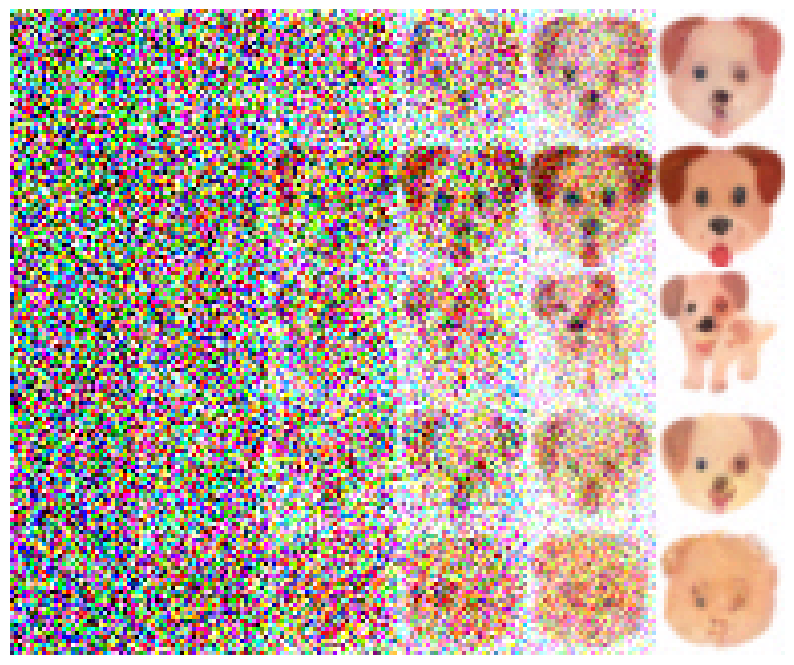

In [20]:
# text = "crying face"  # seen example, good generations
text = " dog "  # seen example, good generations
# text = "crying face with cowboy hat"  # unseen example, bad generations
text_emb = get_text_emb(text)
text_emb = text_emb[None].expand(5, -1).to(device)


img = trainer.diffusion_model.sample(
    batch_size=5,
    model_kwargs={"text_emb": text_emb},
    return_all_timesteps=True
)
show_images(img[:, ::20])

## 无分类器引导

生成模型通常根据保真度（即生成样本的质量或真实感）和多样性（即样本的变化程度或对样本空间的覆盖程度）进行评估。对于条件生成模型，保真度还表示生成样本遵循输入条件的程度。这两个指标往往相互制约，需要进行权衡。Ho 等人提出了一种名为无分类器引导 [3] 的简单技术，可以显式控制这种权衡。

在无分类器引导中，训练条件扩散模型 $\epsilon_\theta(x_t, t, c)$ 时，会以一定概率（通常为 0.1 到 0.2）随机丢弃条件 $c$，即将其替换为 $c=\phi$。在采样的每个去噪步骤中，预测按如下方式更新：
$$\epsilon_\theta(x_t, t, c) \leftarrow (w+1) \epsilon_\theta(x_t, t, c) - w \epsilon_\theta(x_t, t, \phi)$$
其中 $w$ 是正标量，即引导尺度。换言之，每个去噪步骤都执行两次预测：一次有条件、一次无条件，再将二者线性组合，使结果偏向条件生成。$w$ 是一个超参数，需要针对特定模型的评估指标进行调节。较大的 $w$ 会使生成结果更忠实于条件，但往往会降低多样性。

[3] Classifier-Free Diffusion Guidance. Jonathan Ho, Tim Salimans. [链接](https://arxiv.org/abs/2207.12598)

在 `cs231n/unet.py` 的 `Unet.cfg_forward` 方法中实现无分类器引导，并在下方测试；相对误差应小于 1e-6。

In [22]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

b = 2
h = w = 4
inp_x = torch.randn(b, 3, h, w)
inp_text_emb = torch.randn(b, condition_dim)
inp_t = torch.tensor([8, 25]).long()
out = unet.forward(x=inp_x, time=inp_t,
                   model_kwargs={"text_emb": inp_text_emb, "cfg_scale": 2.31}
                   ).detach().numpy()
expected_out = np.array(
      [[[[ 0.3063889,   0.49175858,  0.53406465,  0.17793494],
         [ 1.0605793,   0.07291106,  0.26333052,  0.2807781 ],
         [ 0.47007525,  1.0033083,   0.15596265,  0.21308547],
         [ 0.6635294,   0.69716704,  0.7332697,  -0.14285703]],
        [[-0.14788617, -0.17531544,  0.06930217,  0.24703366],
         [ 0.2998472,  -0.25145096,  0.06968095,  0.28924388],
         [ 0.311122,    0.35599577,  0.6346719,  -0.30859607],
         [ 0.3706389,   0.33177835,  0.29829532,  0.11159261]],
        [[ 0.34566414,  0.79019654,  0.6489645,   0.5683719 ],
         [ 0.98117805,  0.176887,    0.6220584,   0.6494926 ],
         [ 0.66813314,  0.90341353,  0.65361,     0.21999073],
         [ 0.73401093,  0.75344837,  0.71971107,  0.32417077]]],
       [[[ 0.46322435, -1.3915588,   1.0951779,   0.37392217],
         [ 0.6877824,   0.14802843, -0.7159017,   0.22476494],
         [-0.28032526,  0.50201464,  0.0972808,   0.23250426],
         [ 0.38375473,  0.86657,     0.4424622,   0.2161349 ]],
        [[-0.34920466, -0.48507357,  0.06529156,  0.29454708],
         [-0.62153226,  0.0083245,   1.7356712,  -0.0690068 ],
         [ 0.7745638,  -0.11548355,  0.237822,    0.22680345],
         [ 0.06337905,  0.7001358,   0.36441565,  0.17163567]],
        [[ 0.16040441, -0.2551211,   0.8887521,   0.11380547],
         [-0.12803352,  0.2783994,   1.4620805,   0.19044566],
         [ 0.9112923,   0.75666,     0.3765695,   0.66629255],
         [ 0.3461262,   1.0881201,   0.6392708,   0.31749305]]]])


print("forward error: ", rel_error(out, expected_out))

Classifier-free guidance scale: 2.31
forward error:  0.0001179221661745567


运行下面的单元格，可视化使用无分类器引导生成的表情符号。也可以随意修改 `cfg_scale` 参数的值。如前所述，由于模型的泛化能力有限，即使使用较高的引导尺度，也不一定能观察到忠实于条件的生成结果。

sampling loop time step:   0%|          | 0/100 [00:00<?, ?it/s]

Classifier-free guidance scale: 1


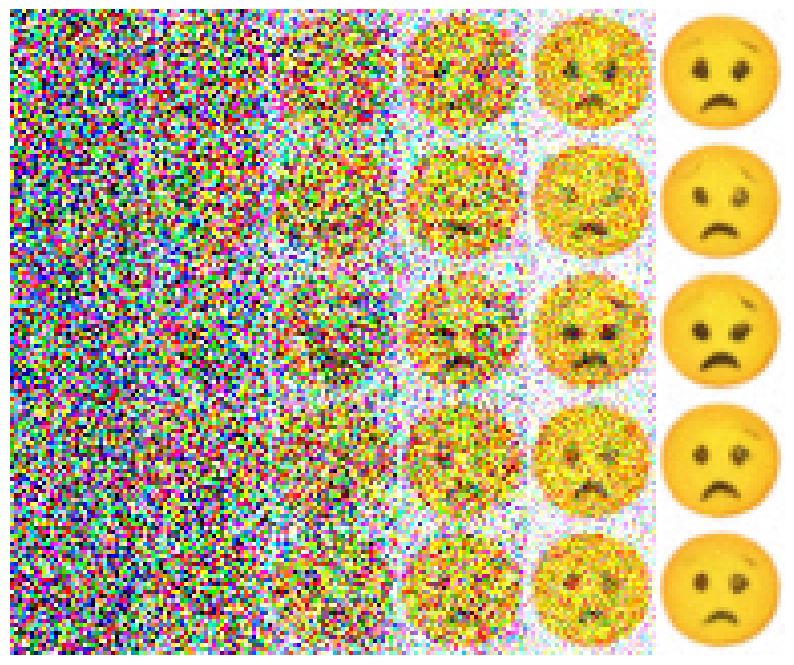

In [43]:
# text = "crying face"  # seen example, good generations
text = "crying baby"  # seen example, good generations
# text = "crying face with cowboy hat"  # unseen example, bad generations
text_emb = get_text_emb(text)
text_emb = text_emb[None].expand(5, -1).to(device)


img = trainer.diffusion_model.sample(
    batch_size=5,
    model_kwargs={"text_emb": text_emb, "cfg_scale": 1},
    return_all_timesteps=True
)
show_images(img[:, ::20])